In [47]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

import pmdarima.arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

In [48]:
df = pd.read_csv('Impute_misvalues_hungyen.csv')
df.head()


,Date,Hour,Waterlevel
0,1/1/2008,0,47.0
1,1/1/2008,1,43.0
2,1/1/2008,2,40.0
3,1/1/2008,3,37.0
4,1/1/2008,4,34.0


In [49]:
df['Hour'] = df['Hour'].replace('#NUM!', 0)

In [50]:
df['Hour'] = pd.to_datetime(df['Hour'], format='%H', errors='coerce').dt.time
df.head()

,Date,Hour,Waterlevel
0,1/1/2008,00:00:00,47.0
1,1/1/2008,01:00:00,43.0
2,1/1/2008,02:00:00,40.0
3,1/1/2008,03:00:00,37.0
4,1/1/2008,04:00:00,34.0


In [51]:
df['Hour'] = df['Hour'].astype(str)
df['Date'] = df['Date'].astype(str)

df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'])
df = df.set_index('DateTime')
df.drop(['Date', 'Hour'], axis = 1, inplace = True)

df.head()

,Waterlevel
DateTime,
2008-01-01 00:00:00,47.0
2008-01-01 01:00:00,43.0
2008-01-01 02:00:00,40.0
2008-01-01 03:00:00,37.0
2008-01-01 04:00:00,34.0


In [52]:
train_size = int(len(df) * 0.7)
train, test = df[:train_size].iloc[:, [-1]], df[train_size:].iloc[:, [-1]]

train, test

(                     Waterlevel
 DateTime                       
 2008-01-01 00:00:00        47.0
 2008-01-01 01:00:00        43.0
 2008-01-01 02:00:00        40.0
 2008-01-01 03:00:00        37.0
 2008-01-01 04:00:00        34.0
 ...                         ...
 2013-02-11 05:00:00        86.0
 2013-02-11 06:00:00       100.0
 2013-02-11 07:00:00       115.0
 2013-02-11 08:00:00       128.0
 2013-02-11 09:00:00       134.0
 
 [44842 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2013-02-11 10:00:00       133.0
 2013-02-11 11:00:00       127.0
 2013-02-11 12:00:00       122.0
 2013-02-11 13:00:00       115.0
 2013-02-11 14:00:00       107.0
 ...                         ...
 2015-04-23 00:00:00       127.0
 2015-04-23 01:00:00       124.0
 2015-04-23 02:00:00       120.0
 2015-04-23 03:00:00       115.0
 2015-04-23 04:00:00       109.0
 
 [19219 rows x 1 columns])

In [53]:
scaler = MinMaxScaler()
train['Waterlevel'] = scaler.fit_transform(train)
test['Waterlevel'] = scaler.transform(test)

In [54]:
train_data = train.values
test_data = test.values
train_data.shape

(44842, 1)

In [55]:
timesteps = 164


In [56]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] 
                               for i in range(0,len(train_data)-timesteps+1)])[:,:,0]

test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] 
                              for i in range(0,len(test_data)-timesteps+1)])[:,:,0]


In [57]:
x_train, y_train = train_data_timesteps[:,:timesteps-1],train_data_timesteps[:,[timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1],test_data_timesteps[:,[timesteps-1]]

x_train, y_train

(array([[0.10782866, 0.10192024, 0.09748892, ..., 0.17282127, 0.16395864,
         0.15509601],
        [0.10192024, 0.09748892, 0.09305761, ..., 0.16395864, 0.15509601,
         0.14623338],
        [0.09748892, 0.09305761, 0.08862629, ..., 0.15509601, 0.14623338,
         0.13737075],
        ...,
        [0.1816839 , 0.17725258, 0.17282127, ..., 0.14327917, 0.16543575,
         0.18611521],
        [0.17725258, 0.17282127, 0.16838996, ..., 0.16543575, 0.18611521,
         0.20827179],
        [0.17282127, 0.16838996, 0.16395864, ..., 0.18611521, 0.20827179,
         0.22747415]]),
 array([[0.14623338],
        [0.13737075],
        [0.12998523],
        ...,
        [0.20827179],
        [0.22747415],
        [0.23633678]]))

In [58]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    r2 = r2_score(y_true, y_pred)
    
    r, _ = pearsonr(y_true, y_pred)
    
    sim, _ = pearsonr(y_true, y_pred)
    
    sd_y = np.std(y_pred)
    sd_x = np.std(y_test)
    fsd = 2 * np.abs(sd_y - sd_x) / (sd_y + sd_x)
    
    nse = 1 - (np.sum((y_pred - y_true) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R': r,
        'SIM': sim,
        'FSD': fsd,
        'NSE': nse
    }

In [59]:
train_ARIMA = scaler.inverse_transform(train_data)
test_ARIMA = scaler.inverse_transform(test_data)
train_ARIMA.shape
test_ARIMA.shape

(19219, 1)

In [60]:
warnings.filterwarnings(category=UserWarning, action='ignore')
arima_model = pmdarima.arima.auto_arima(train_ARIMA, seasonal=False, 
                                        error_action='ignore', trace=True,
                                        suppress_warnings=True, maxiter=20, stepwise=True,
                                        n_jobs=2)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=200980.726, Time=14.72 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=289610.714, Time=0.59 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=216400.279, Time=1.40 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=248451.402, Time=4.32 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=289608.719, Time=0.34 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=207092.816, Time=6.25 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=201845.967, Time=13.29 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=201859.951, Time=15.48 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=200607.340, Time=17.74 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=206436.578, Time=9.23 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=200572.517, Time=18.61 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=200280.772, Time=21.41 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=21.80 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=200378.544, Time=25.46 sec
 ARI

In [61]:
arima_model.fit(train_ARIMA)

ARIMA(maxiter=20, order=(5, 1, 3), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [62]:
predictions_arima = arima_model.predict(start=0, end=len(train_data)-1+len(test_data),n_periods = len(train_data)+len(test_data))
predictions_arima

array([135.96263265, 134.36120291, 130.62252551, ...,  97.25575895,
        97.25575895,  97.25575895])

In [63]:
res = df["Waterlevel"]- predictions_arima
res.shape

(64061,)

In [64]:
train_size_res = int(len(res) * 0.7)
res_train = res[:train_size_res]
res_test = res[train_size_res:]


In [65]:
train_res=np.array([[j for j in res_train.values.reshape(-1,1)[i:i+timesteps]] 
                               for i in range(0,len(train_data)-timesteps+1)])[:,:,0]

test_res=np.array([[j for j in res_test.values.reshape(-1,1)[i:i+timesteps]] 
                              for i in range(0,len(test_data)-timesteps+1)])[:,:,0]

In [66]:
x_train, y_train = train_res[:,:timesteps-1],train_res[:,[timesteps-1]]
x_test, y_test = test_res[:,:timesteps-1],test_res[:,[timesteps-1]]

x_train, y_train

(array([[-88.96263265, -91.36120291, -90.62252551, ...,  -6.25883835,
         -12.26169904, -18.26386897],
        [-91.36120291, -90.62252551, -88.35310749, ..., -12.26169904,
         -18.26386897, -24.26526156],
        [-90.62252551, -88.35310749, -84.61677521, ..., -18.26386897,
         -24.26526156, -30.26585312],
        ...,
        [ -0.25575895,  -3.25575895,  -6.25575895, ..., -26.25575895,
         -11.25575895,   2.74424105],
        [ -3.25575895,  -6.25575895,  -9.25575895, ..., -11.25575895,
           2.74424105,  17.74424105],
        [ -6.25575895,  -9.25575895, -12.25575895, ...,   2.74424105,
          17.74424105,  30.74424105]]),
 array([[-24.26526156],
        [-30.26585312],
        [-35.26567856],
        ...,
        [ 17.74424105],
        [ 30.74424105],
        [ 36.74424105]]))

In [67]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    r, _ = pearsonr(y_true, y_pred)
    
    T = len(y_true)
    max_x = max(y_true)
    min_x = min(y_true)
    
    sim_sum = 0
    for i in range(T):
        sim_sum += 1 / (1 + abs(y_pred[i] - y_true[i]) / (max_x - min_x))
    sim = sim_sum / T
    
    sd_y = np.std(y_pred)
    sd_x = np.std(y_test)
    fsd = 2 * np.abs(sd_y - sd_x) / (sd_y + sd_x)
    
    nse = 1 - (np.sum((y_pred - y_true) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R': r,
        'SIM': sim,
        'FSD': fsd,
        'NSE': nse
    }

## ARIMA + RF

In [68]:
model_RF = RandomForestRegressor(n_estimators=100, max_features=6, random_state=42)

model_RF.fit(x_train, y_train[:,0])

RandomForestRegressor(max_features=6, random_state=42)

In [69]:
hours = 120
def forecast_value (model, hours):
    current_window = x_train[-1,:].tolist()

    predict = []

    for _ in range(hours):
        next_value = model.predict([current_window])[0]
        predict.append(next_value)
        
        current_window.pop(0)  
        current_window.append(next_value)
    predict_array = np.array(predict).reshape(-1, 1)
    return(predict_array)
predict_RF = forecast_value(model_RF, hours)    

In [70]:
predict_RF

array([[ 37.19424105],
       [ 40.34924105],
       [ 40.40924105],
       [ 37.12424105],
       [ 33.05424105],
       [ 26.44424105],
       [ 19.77924105],
       [ 12.08424105],
       [  5.35424105],
       [ -1.45075895],
       [ -8.14575895],
       [-13.72075895],
       [-22.57075895],
       [-29.79575895],
       [-35.93575895],
       [-43.10075895],
       [-50.10575895],
       [-52.14575895],
       [-50.85075895],
       [-42.18075895],
       [-27.83075895],
       [-14.79575895],
       [ -1.59575895],
       [  9.34924105],
       [ 14.03424105],
       [ 17.81924105],
       [ 16.20424105],
       [ 15.85924097],
       [ 11.84924105],
       [  9.52424105],
       [  3.67424105],
       [ -0.88575905],
       [ -6.90575903],
       [-13.42075895],
       [-19.61575895],
       [-24.20575895],
       [-27.39075895],
       [-35.58075895],
       [-41.23575895],
       [-47.67075895],
       [-52.2957589 ],
       [-57.69075894],
       [-60.29075895],
       [-55

In [71]:
predict_ARIMA_RF = predictions_arima[train_size_res:][:120] + predict_RF.flatten()
predict_ARIMA_RF

array([134.45      , 137.605     , 137.665     , 134.38      ,
       130.31      , 123.7       , 117.035     , 109.34      ,
       102.61      ,  95.805     ,  89.11      ,  83.535     ,
        74.685     ,  67.46      ,  61.32      ,  54.155     ,
        47.15      ,  45.11      ,  46.405     ,  55.075     ,
        69.425     ,  82.46      ,  95.66      , 106.605     ,
       111.29      , 115.075     , 113.46      , 113.11499993,
       109.105     , 106.78      , 100.93      ,  96.3699999 ,
        90.34999992,  83.835     ,  77.64      ,  73.05      ,
        69.865     ,  61.675     ,  56.02      ,  49.585     ,
        44.96000005,  39.56500001,  36.965     ,  41.655     ,
        51.94      ,  65.305     ,  74.11      ,  88.21      ,
        91.63      ,  95.99      ,  98.91      ,  99.05      ,
        97.1       ,  93.47      ,  88.86999992,  86.015     ,
        82.51      ,  76.415     ,  73.04      ,  69.065     ,
        64.69      ,  62.11500001,  56.55000003,  50.31

In [72]:
metrics_ARIMA = calculate_metrics(test_ARIMA[:hours].flatten(), predict_ARIMA_RF[:hours].flatten())
for metric, value in metrics_ARIMA.items():
    print(f'Using model ARIMA {metric}: {value}')

Using model ARIMA MAE: 17.760791701953355
Using model ARIMA RMSE: 23.54126066442044
Using model ARIMA R: 0.8338860463863618
Using model ARIMA SIM: 0.8833696422916365
Using model ARIMA FSD: 1.0228583884049816
Using model ARIMA NSE: 0.3413139473918849


## SVR

In [73]:
scaler = MinMaxScaler()
res_train_tf = scaler.fit_transform(res_train.values.reshape(-1, 1))
res_test_tf = scaler.transform(res_test.values.reshape(-1, 1))


In [74]:
train_res_tf=np.array([[j for j in res_train_tf[i:i+timesteps]] 
                               for i in range(0,len(train_data)-timesteps+1)])[:,:,0]

test_res_tf=np.array([[j for j in res_test_tf[i:i+timesteps]] 
                              for i in range(0,len(test_data)-timesteps+1)])[:,:,0]

In [75]:
x_train_tf, y_train_tf = train_res_tf[:,:timesteps-1],train_res_tf[:,[timesteps-1]]
x_test_tf, y_test_tf = test_res_tf[:,:timesteps-1],test_res_tf[:,[timesteps-1]]


In [76]:
x_train.shape , y_train.shape

((44679, 163), (44679, 1))

In [77]:
# x_train.shape

In [78]:
model_SVR = SVR(kernel='rbf',gamma=0.001, C=50, epsilon = 0.005)
model_SVR.fit(x_train_tf, y_train_tf[:,0])

SVR(C=50, epsilon=0.005, gamma=0.001)

In [79]:
def forecast_value_tf (model, hours):
    current_window = x_train_tf[-1,:].tolist()

    predict = []

    for _ in range(hours):
        next_value = model.predict([current_window])[0]
        predict.append(next_value)
        
        current_window.pop(0)  
        current_window.append(next_value)
    predict_array = np.array(predict).reshape(-1, 1)
    return(predict_array)
predict_RF = forecast_value(model_RF, hours) 

In [80]:
hours = 120
predict_SVR = forecast_value_tf (model_SVR, hours) 
predict_SVR

array([[0.2383956 ],
       [0.24222756],
       [0.2386367 ],
       [0.23122848],
       [0.22296257],
       [0.21473768],
       [0.20589399],
       [0.19604086],
       [0.18568515],
       [0.17511686],
       [0.16455182],
       [0.1541888 ],
       [0.14472748],
       [0.13658642],
       [0.12932799],
       [0.12177633],
       [0.11402904],
       [0.10937867],
       [0.11254582],
       [0.12533868],
       [0.14455079],
       [0.16537844],
       [0.18527804],
       [0.20361116],
       [0.21900287],
       [0.22930635],
       [0.23256002],
       [0.22982396],
       [0.2239618 ],
       [0.21786795],
       [0.21235211],
       [0.20661414],
       [0.1999115 ],
       [0.19240514],
       [0.18428642],
       [0.17560343],
       [0.16673708],
       [0.15835871],
       [0.15103639],
       [0.1442049 ],
       [0.13696773],
       [0.1297815 ],
       [0.12580566],
       [0.12837534],
       [0.13822019],
       [0.15247851],
       [0.16784583],
       [0.182

In [81]:
predict_SVR = scaler.inverse_transform(predict_SVR)

In [82]:
predict_ARIMA_SVR = predictions_arima[train_size_res:][:120] + predict_SVR.flatten()
predict_ARIMA_SVR

array([135.39382418, 137.98805634, 135.55704301, 130.54168357,
       124.94566296, 119.37740657, 113.3902321 , 106.7196643 ,
        99.70884357,  92.55411272,  85.40158395,  78.38581443,
        71.98050235,  66.46900595,  61.55504643,  56.44257342,
        51.19766334,  48.04936001,  50.19352275,  58.85428519,
        71.86088151,  85.96120627,  99.43323036, 111.84475302,
       122.26494069, 129.24040083, 131.44313469, 129.59082094,
       125.62213757, 121.49660107, 117.76238044, 113.87777319,
       109.34008354, 104.25828133,  98.76190925,  92.88352525,
        86.88100425,  81.20884555,  76.25163784,  71.62671724,
        66.72715201,  61.86207706,  59.17043395,  60.91010417,
        67.5750706 ,  77.22795284,  87.6316246 ,  97.49083766,
       106.36553972, 113.48494551, 117.60792161, 118.04430606,
       115.65198197, 112.19915173, 109.40570031, 107.71847969,
       106.54863152, 105.14814137, 103.10733597, 100.30060804,
        96.77642304,  92.69267048,  88.5892859 ,  84.67

In [83]:
metrics_ARIMA = calculate_metrics(test_ARIMA[:hours].flatten(), predict_ARIMA_SVR[:hours].flatten())
for metric, value in metrics_ARIMA.items():
    print(f'Using model ARIMA_SVR {metric}: {value}')

Using model ARIMA_SVR MAE: 38.834518766839786
Using model ARIMA_SVR RMSE: 44.33774930737034
Using model ARIMA_SVR R: 0.6738831184480314
Using model ARIMA_SVR SIM: 0.772709795690007
Using model ARIMA_SVR FSD: 1.1582896173562864
Using model ARIMA_SVR NSE: -1.33650288826643


## KNN

In [84]:
knn_regressor = KNeighborsRegressor(n_neighbors=6)
knn_regressor.fit(x_train_tf, y_train_tf[:,0])

KNeighborsRegressor(n_neighbors=6)

In [85]:
predict_KNN = forecast_value_tf(knn_regressor, hours)

In [86]:
predict_KNN = scaler.inverse_transform(predict_KNN)

In [87]:
predict_KNN

array([[ 41.57757438],
       [ 46.07757438],
       [ 46.91090772],
       [ 42.07757438],
       [ 36.07757438],
       [ 30.07757438],
       [ 23.74424105],
       [ 17.41090772],
       [ 10.24424105],
       [  3.07757438],
       [ -4.00575895],
       [-11.25575895],
       [-18.25575895],
       [-25.08909228],
       [-31.50575895],
       [-41.92242562],
       [-46.92242562],
       [-48.75575895],
       [-48.25575895],
       [-38.25575895],
       [-23.58909228],
       [-10.42242562],
       [  1.24424105],
       [ 10.74424105],
       [ 19.24424105],
       [ 18.74424105],
       [ 19.41090772],
       [ 10.24424105],
       [  5.41090772],
       [ -0.58909228],
       [ -2.25575895],
       [ -7.92242562],
       [-13.08909228],
       [-18.42242562],
       [-24.58909228],
       [-32.58909228],
       [-39.25575895],
       [-40.42242562],
       [-45.25575895],
       [-49.75575895],
       [-53.92242562],
       [-55.75575895],
       [-52.92242562],
       [-45

In [88]:
predict_ARIMA_KNN = predictions_arima[train_size_res:][:120] + predict_KNN.flatten()
predict_ARIMA_KNN

array([138.83333333, 143.33333333, 144.16666667, 139.33333333,
       133.33333333, 127.33333333, 121.        , 114.66666667,
       107.5       , 100.33333333,  93.25      ,  86.        ,
        79.        ,  72.16666667,  65.75      ,  55.33333333,
        50.33333333,  48.5       ,  49.        ,  59.        ,
        73.66666667,  86.83333333,  98.5       , 108.        ,
       116.5       , 116.        , 116.66666667, 107.5       ,
       102.66666667,  96.66666667,  95.        ,  89.33333333,
        84.16666667,  78.83333333,  72.66666667,  64.66666667,
        58.        ,  56.83333333,  52.        ,  47.5       ,
        43.33333333,  41.5       ,  44.33333333,  51.66666667,
        61.66666667,  72.33333333,  82.83333333,  92.5       ,
       100.33333333, 102.5       , 104.16666667, 104.83333333,
       101.83333333,  97.83333333,  92.83333333,  89.16666667,
        82.5       ,  78.33333333,  74.58333333,  61.83333333,
        56.5       ,  51.5       ,  46.41666667,  41.25

In [89]:
metrics_ARIMA = calculate_metrics(test_ARIMA[:hours].flatten(), predict_ARIMA_KNN[:hours].flatten())
for metric, value in metrics_ARIMA.items():
    print(f'Using model ARIMA {metric}: {value}')

Using model ARIMA MAE: 19.63958333333333
Using model ARIMA RMSE: 25.17051226137442
Using model ARIMA R: 0.8341354000160274
Using model ARIMA SIM: 0.87188967508413
Using model ARIMA FSD: 0.9704778309536006
Using model ARIMA NSE: 0.2469858386228817


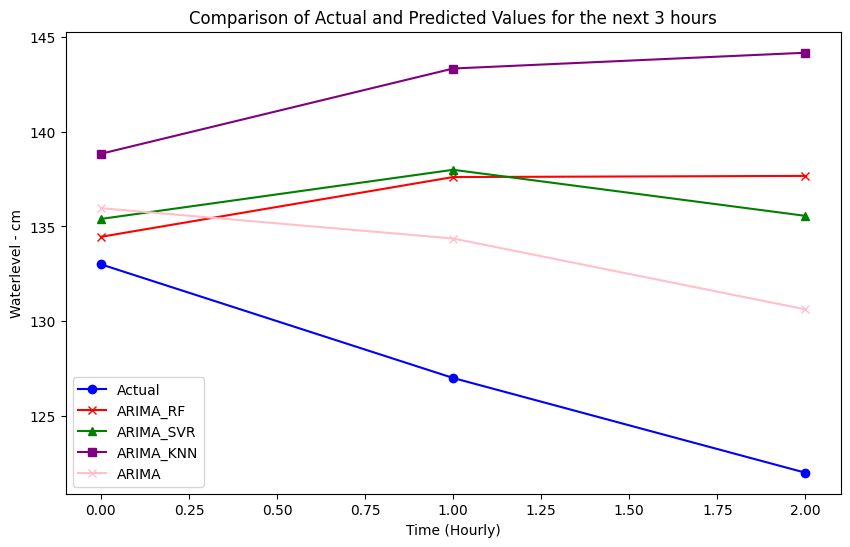

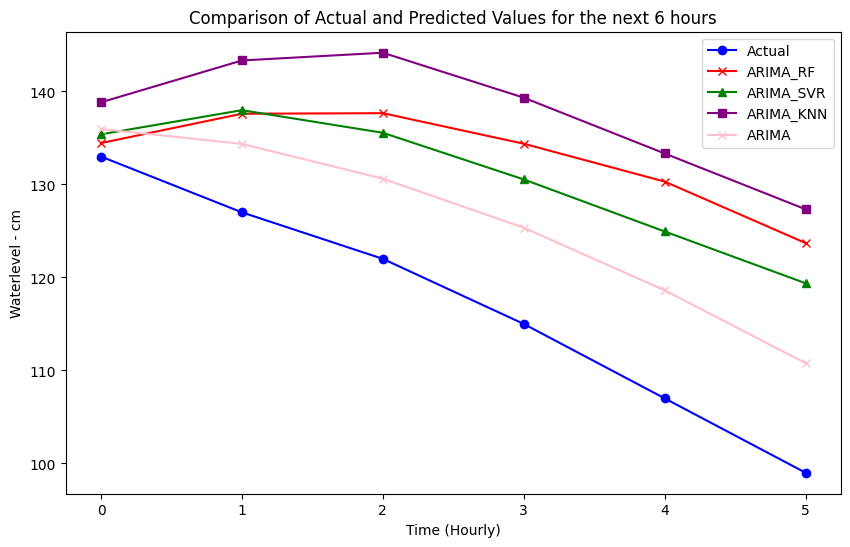

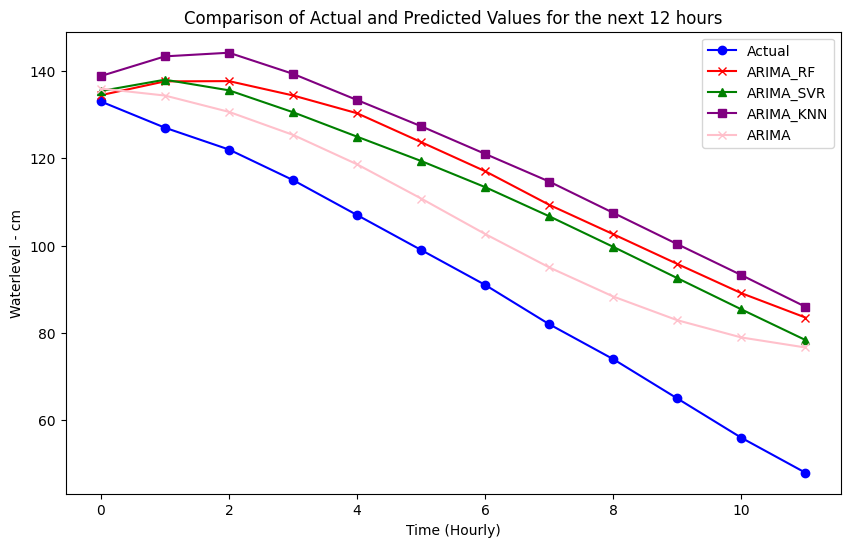

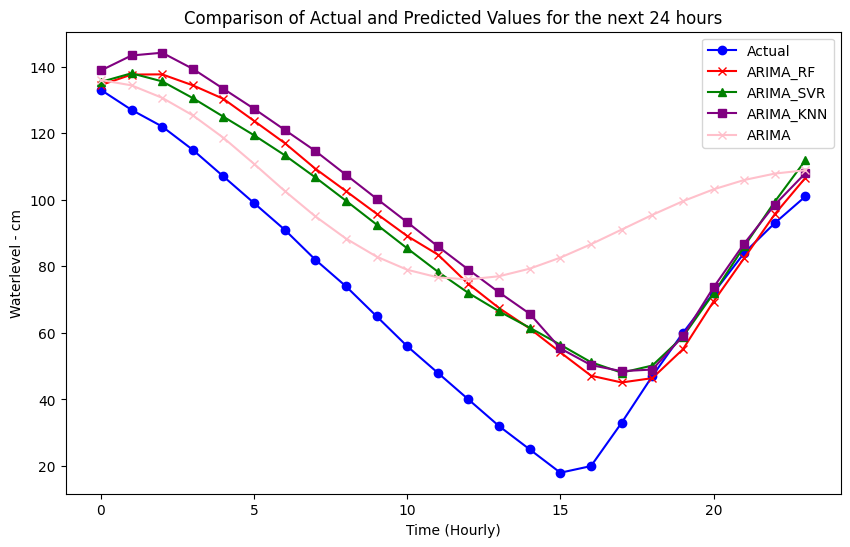

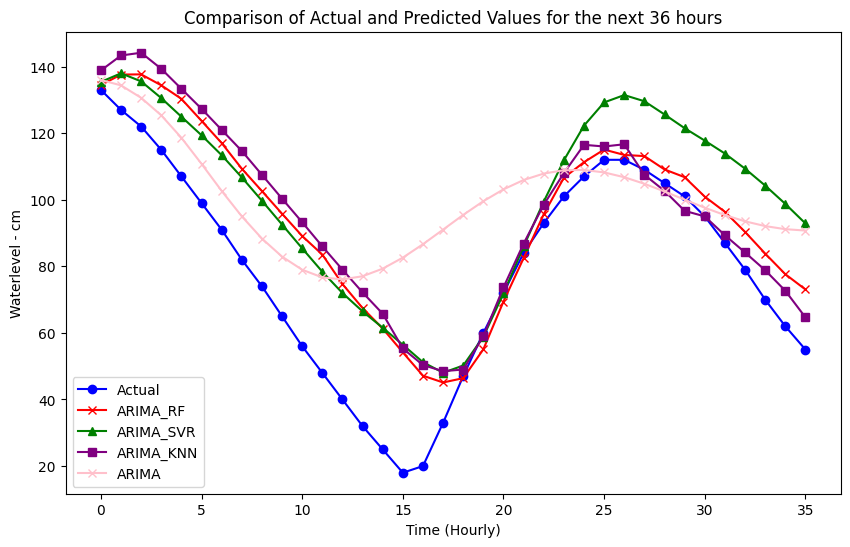

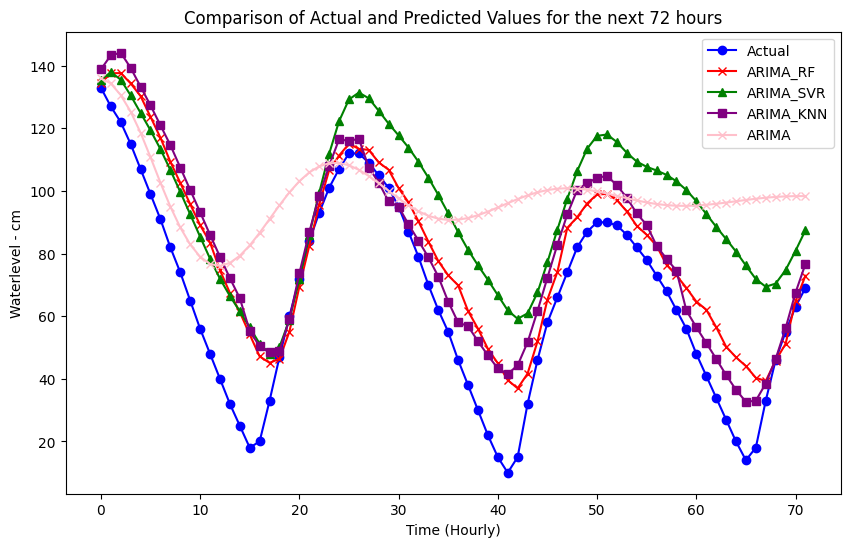

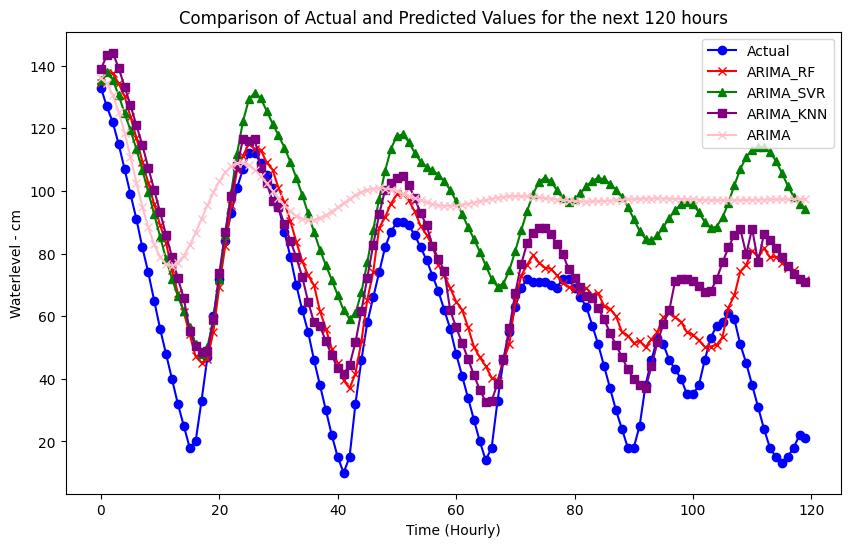

In [90]:
time_forecast = [3,  6, 12, 24, 36, 72, 120]
for hours in time_forecast:
    plt.figure(figsize=(10, 6))
    
    plt.plot(test_ARIMA[:hours], label='Actual', color='blue', marker='o')
    plt.plot(predict_ARIMA_RF.flatten()[:hours], label='ARIMA_RF', color='red', marker='x')
    plt.plot(predict_ARIMA_SVR.flatten()[:hours], label='ARIMA_SVR', color='green', marker='^')
    plt.plot(predict_ARIMA_KNN.flatten()[:hours], label='ARIMA_KNN', color='purple', marker='s')
    plt.plot(predictions_arima.flatten()[:hours], label='ARIMA', color='pink', marker='x')
    
    
    plt.title(f'Comparison of Actual and Predicted Values for the next {hours} hours')
    plt.xlabel('Time (Hourly)')
    plt.ylabel('Waterlevel - cm')
    plt.legend()

    plt.show()